# Clasificación de Noticias

## Data Preparation

In [3]:
from gensim.models import KeyedVectors
import os

w2v_model = KeyedVectors.load('../../Representacion_del_lenguaje/embeddings/NoContext/w2v_sg.kv', mmap='r')
print(w2v_model)

KeyedVectors<vector_size=300, 16863 keys>


Para modelos de Deep Learning con redes neuronales, necesitamos una representación diferente a la usada en Shallow Learning. Mientras que para modelos clásicos (Regresión Logística, SVM) promediamos los vectores Word2Vec de todas las palabras en un solo vector de 300 dimensiones, para CNNs necesitamos tener en cuanta la secuencia de palabras en el texto. Cada texto se representa como una matriz 3D donde cada palabra mantiene su posición y su vector Word2Vec de 300 dimensiones.

In [4]:
import numpy as np
import os

load_x_test = array = np.load("w2v_splits/X_w2v_test.npy", allow_pickle=True)
load_x_train = array = np.load("w2v_splits/X_w2v_train.npy", allow_pickle=True)
load_y_test = array = np.load("w2v_splits/y_w2v_test.npy", allow_pickle=True)
load_y_train = array = np.load("w2v_splits/y_w2v_train.npy", allow_pickle=True)

print("Training set size:", len(load_x_train))
print("Test set size:", len(load_x_test))

Training set size: 4128
Test set size: 1032


Importamos los mismos splits utilizados en *shallow learning* para aplicarles el modelo `Word2Vec`. Transformamos cada texto en una matriz 2D de dimensiones (MAX_LEN, 300). Para cada texto tokenizamos las palabras; para cada posición hasta `MAX_LEN=250`, colocamos el vector Word2Vec de 300 dimensiones de esa palabra; si la palabra no está en el vocabulario o el texto es más corto que MAX_LEN, rellenamos con ceros (padding). El resultado final es una matriz 3D de dimensiones (num_textos, 250, 300) donde cada "paso temporal" corresponde a una palabra en su posición original. Esta representación secuencial permite que la CNN capture patrones locales como bigramas o trigrams (kernel_size) sirven para entender el contexto y significado del texto.

In [5]:
import numpy as np
import nltk

MAX_LEN = 250
EMBEDDING_DIM = 300

def crear_secuencias_vectores(texts, modelo_w2v, max_len):
    textos_tokenizados = [nltk.word_tokenize(texto.lower()) for texto in texts]
    num_textos = len(textos_tokenizados)
    # Matriz de ceros
    data_matrix = np.zeros((num_textos, max_len, EMBEDDING_DIM))
    
    for i, texto in enumerate(textos_tokenizados):
        # Para cada palabra en el texto
        for j, palabra in enumerate(texto):
            if j >= max_len:
                break
            
            # Si la palabra existe ponemos su vector
            if palabra in modelo_w2v:
                data_matrix[i, j, :] = modelo_w2v[palabra]
            # Si no existe, se queda en ceros
            
    return data_matrix

In [6]:
from sklearn.preprocessing import LabelEncoder

xw2v_train_global= crear_secuencias_vectores(load_x_train, w2v_model, MAX_LEN)
xw2v_test_global = crear_secuencias_vectores(load_x_test, w2v_model, MAX_LEN)

label_encoder = LabelEncoder()
y_train_global = label_encoder.fit_transform(load_y_train)
y_test_global = label_encoder.transform(load_y_test)

Codificamos las etiquetas de texto a números (0-4) usando LabelEncoder. Los datos de entrenamiento tienen forma (4128, 250, 300): 4128 textos, cada uno con 250 palabras de 300 dimensiones.

In [7]:
print("Clases codificadas:")
for i, clase in enumerate(label_encoder.classes_):
    print(f"{i}: {clase}")

Clases codificadas:
0: Business Growth and Cloud Infrastructure in the AI Industry
1: Financial and Market News and Corporate Sales
2: Informal / Conversational Lenguaje
3: Quantum Computing and Military Technology
4: Stock Market and Trading


In [8]:
print("\nTextos (variable predictoria):\n", "Training", xw2v_train_global.shape, "Test", xw2v_test_global.shape)
print("Topics (variable a predecir):\n", "Training", y_train_global.shape, "Test", y_test_global.shape)


Textos (variable predictoria):
 Training (4128, 250, 300) Test (1032, 250, 300)
Topics (variable a predecir):
 Training (4128,) Test (1032,)


In [9]:
print("Ejemplo de secuencia vectorizada:\n")
print(xw2v_train_global[0])
print("\nEtiqueta correspondiente:\n", y_train_global[0])

Ejemplo de secuencia vectorizada:

[[ 0.05511087 -0.16394104 -0.14337887 ... -0.17383268 -0.08027928
   0.35748944]
 [-0.07079615 -0.03115544 -0.08904827 ... -0.03574318 -0.38465467
  -0.15072538]
 [ 0.00060616 -0.02032229 -0.01909479 ...  0.03317554 -0.03860329
   0.15451004]
 ...
 [ 0.08557452  0.2473056   0.22726507 ... -0.0585891  -0.21866538
   0.17859516]
 [-0.21854267 -0.11034933 -0.11211472 ...  0.27792314 -0.18461601
  -0.34341264]
 [-0.47109169  0.32672158 -0.18861964 ...  0.14943372 -0.18867269
  -0.11687194]]

Etiqueta correspondiente:
 0


In [10]:
import pandas as pd
topics = pd.read_csv("../../../data/definitivos/INDEX_ALL_scrapped_filtrado.csv")
y = topics["topic"].values

print("\nDistribución de textos por topic:")
print(topics["topic"].value_counts().sort_index())


Distribución de textos por topic:
topic
Business Growth and Cloud Infrastructure in the AI Industry    1539
Financial and Market News and Corporate Sales                  2257
Informal / Conversational Lenguaje                              152
Quantum Computing and Military Technology                       101
Stock Market and Trading                                       1111
Name: count, dtype: int64


### Pretrained *Word2Vec*

Para comparar resultados, vamos a utilizar un [modelo Word2Vec preentrenado por Google](https://github.com/mmihaltz/word2vec-GoogleNews-vectors/blob/master/GoogleNews-vectors-negative300.bin.gz) en 3 millones de noticias de Google News (aproximadamente 100 mil millones de palabras). Este modelo contiene vectores de 300 dimensiones para 3 millones de palabras y frases, entrenado con un corpus masivo y diverso. La ventaja de usar embeddings preentrenados es que capturan conocimiento lingüístico general aprendido de grandes volúmenes de texto.

In [11]:
w2v_pretrained_model = KeyedVectors.load_word2vec_format('../../models/GoogleNews-vectors-negative300.bin.gz', binary=True)
print(w2v_pretrained_model)

KeyedVectors<vector_size=300, 3000000 keys>


Esta representación alternativa nos permitirá evaluar en el entrenamiento de la CNN si los embeddings genéricos de alta calidad superan a los embeddings especializados pero entrenados con menos datos.

In [12]:
xw2v_train_pretrained = crear_secuencias_vectores(load_x_train, w2v_pretrained_model, MAX_LEN)
xw2v_test_pretrained = crear_secuencias_vectores(load_x_test, w2v_pretrained_model, MAX_LEN)

print("Textos con Word2Vec preentrenado:\n", "Training", xw2v_train_pretrained.shape, "Test", xw2v_test_pretrained.shape)

Textos con Word2Vec preentrenado:
 Training (4128, 250, 300) Test (1032, 250, 300)


In [13]:
print(xw2v_train_pretrained[0])

[[-0.05200195  0.06176758 -0.13671875 ... -0.0703125  -0.17285156
   0.10546875]
 [-0.04492188 -0.03039551  0.00234985 ...  0.01226807 -0.08837891
  -0.015625  ]
 [ 0.02734375  0.15527344 -0.05053711 ... -0.03320312 -0.15625
   0.11230469]
 ...
 [-0.02685547 -0.34570312  0.10498047 ...  0.04077148 -0.33789062
   0.12353516]
 [-0.19238281 -0.3203125   0.32617188 ... -0.359375    0.04589844
  -0.11328125]
 [ 0.05541992 -0.19628906 -0.06835938 ...  0.04736328  0.0625
   0.14160156]]


## Convolutional Neural Network

Implementamos una Red Neuronal Convolucional (CNN) para clasificación de texto. La red sigue la siguiente arquitectura:

- Capa Conv1D con 128 filtros y kernel_size=5, que detecta patrones de 5 palabras consecutivas
- GlobalMaxPooling1D que extrae la característica más importante de cada filtro, reduciendo dimensionalidad
- Capa densa de 64 neuronas que combina los patrones detectados
- Dropout del 50% para regularización y prevenir overfitting
- Capa de salida con 5 neuronas y softmax para clasificación multiclase.

Usamos *sparse_categorical_crossentropy* como función de pérdida (apropiada para etiquetas codificadas como enteros) y Adam como optimizador.

In [18]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from keras.optimizers import Adam

def modelo_cnn(input_shape, num_filtros=128, kernel_size=5, lr=0.001, dropout=0.5):
    model = Sequential()

    # Capa de entrada explícita
    model.add(Input(shape=input_shape))
    
    # Bloque convolucional
    # Mirar grupos de 5 palabras
    model.add(Conv1D(filters=num_filtros, 
                     kernel_size=kernel_size, 
                     activation='relu'))
    
    # Reduce la dimensionalidad quedándose con el valor más alto (el rasgo más fuerte)
    model.add(GlobalMaxPooling1D())

    # Bloque denso (Clasificación)
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout))

    # Salida
    model.add(Dense(5, activation='softmax'))

    # Compilación
    optimizer = Adam(learning_rate=lr)
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy'])

    return model

Entrenamos la CNN con una partición interna del 20% del conjunto de entrenamiento para validación. Tras el entrenamiento medimos el rendimiento en el conjunto de test externo y reportamos tanto accuracy como F1 ponderado (útil para clases desbalanceadas).

In [19]:
from sklearn.metrics import f1_score
import numpy as np

# Dimensiones de entrada para la CNN
input_shape = (xw2v_train_global.shape[1], xw2v_train_global.shape[2])
print(f"Entrenando CNN (embeddings propios) con input shape: {input_shape}...")

# Entrenar con un 20% del train como validación
cnn_global = modelo_cnn(input_shape, num_filtros=128, kernel_size=5, dropout=0.5)
cnn_global.fit(
    xw2v_train_global,
    y_train_global,
    validation_split=0.2,
    epochs=6,
    batch_size=32,
    verbose=1,
)

# Evaluar en el test externo
loss_cnn_global, acc_cnn_global = cnn_global.evaluate(xw2v_test_global, y_test_global, verbose=0)
y_pred_test = np.argmax(cnn_global.predict(xw2v_test_global, verbose=0), axis=1)
f1_cnn_global = f1_score(y_test_global, y_pred_test, average="weighted")

print("\n" + "=" * 30)
print(f"ACCURACY TEST: {acc_cnn_global:.4f}")
print(f"F1 TEST (weighted): {f1_cnn_global:.4f}")

Entrenando CNN (embeddings propios) con input shape: (250, 300)...
Epoch 1/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.5678 - loss: 1.0911 - val_accuracy: 0.7906 - val_loss: 0.6719
Epoch 2/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.7771 - loss: 0.6277 - val_accuracy: 0.8354 - val_loss: 0.4935
Epoch 3/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8649 - loss: 0.4139 - val_accuracy: 0.8269 - val_loss: 0.4723
Epoch 4/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9140 - loss: 0.2741 - val_accuracy: 0.8426 - val_loss: 0.4249
Epoch 5/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9440 - loss: 0.1821 - val_accuracy: 0.8753 - val_loss: 0.3498
Epoch 6/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9688 - loss: 0.1193 - val_accuracy: 0.8753 - val_loss: 0.3715

ACCURACY TEST: 0.8711
F1 TEST (weighted): 0.8679


### Usando vectores de Google News

In [20]:
from sklearn.metrics import f1_score
import numpy as np

input_shape = (xw2v_train_pretrained.shape[1], xw2v_train_pretrained.shape[2])
print(f"Entrenando CNN (Google News) con input shape: {input_shape}...")

cnn_pretrained = modelo_cnn(input_shape, num_filtros=128, kernel_size=5, dropout=0.5)
cnn_pretrained.fit(
    xw2v_train_pretrained,
    y_train_global,
    validation_split=0.2,
    epochs=6,
    batch_size=32,
    verbose=1,
)

loss_cnn_pretrained, acc_cnn_pretrained = cnn_pretrained.evaluate(xw2v_test_pretrained, y_test_global, verbose=0)
y_pred_test = np.argmax(cnn_pretrained.predict(xw2v_test_pretrained, verbose=0), axis=1)
f1_cnn_pretrained = f1_score(y_test_global, y_pred_test, average="weighted")

print("\n" + "=" * 30)
print(f"ACCURACY TEST: {acc_cnn_pretrained:.4f}")
print(f"F1 TEST (weighted): {f1_cnn_pretrained:.4f}")

Entrenando CNN (Google News) con input shape: (250, 300)...
Epoch 1/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.5854 - loss: 1.0505 - val_accuracy: 0.7627 - val_loss: 0.7376
Epoch 2/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.7444 - loss: 0.6983 - val_accuracy: 0.7724 - val_loss: 0.5824
Epoch 3/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.8343 - loss: 0.4863 - val_accuracy: 0.8559 - val_loss: 0.4371
Epoch 4/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.8952 - loss: 0.3239 - val_accuracy: 0.8644 - val_loss: 0.3995
Epoch 5/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.9397 - loss: 0.2154 - val_accuracy: 0.8765 - val_loss: 0.3728
Epoch 6/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.9567 - loss: 0.1561 - val_accuracy: 0.8717 - val_loss: 0.3780

ACCURACY TEST: 0.8421
F1 TEST (weighted): 0.8401


La comparación entre los embeddings Word2Vec entrenados por nosotros y los preentrenados de Google News revela que ningun modelo presenta una mejora significante del accuracy, por lo que el vocabulario especializado en finanzas y el contexto específico del dominio tienen el mismo valor que la cobertura general. La falta de especialización no implica que la calidad general de los embeddings sea mas elevada, por lo que el vocabulario mas amplio y general no es más importante que el dominio específico para este problema.

## Bi-LSTM

Para esta estructura, usamos la API Funcional de Keras en lugar de *Sequential*, porque nos permite hacer la bifurcación del Pooling (calcular Max y Mean en paralelo y luego unirlos) de forma muy limpia.

In [22]:
import tensorflow as tf
from keras.layers import Input, Bidirectional, LSTM, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate, Dense, Dropout
from keras.models import Model

def modelo_bilstm_pooling(input_shape, num_filtros=128, lr=0.001, dropout=0.5):
    
    inputs = Input(shape=input_shape)

    # Layer Bi-LSTM (256 neuronas)
    x = Bidirectional(LSTM(num_filtros, return_sequences=True))(inputs)

    # El Bloque de Pooling (Igual que antes)
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    x = Concatenate()([avg_pool, max_pool])

    # Layer densa intermedia (64 neuronas)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)

    # Salida
    outputs = Dense(5, activation='softmax')(x)

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

Entrenamos la Bi-LSTM usando un 20% del conjunto de entrenamiento como validación interna. Luego evaluamos en el conjunto de test externo y reportamos accuracy y F1 ponderado.

In [23]:
from sklearn.metrics import f1_score
import numpy as np

# Dimensiones de entrada para la Bi-LSTM
input_shape = (xw2v_train_global.shape[1], xw2v_train_global.shape[2])
print(f"Entrenando Bi-LSTM (embeddings propios) con input shape: {input_shape}...")

bilstm_global = modelo_bilstm_pooling(input_shape, num_filtros=128, dropout=0.5)
bilstm_global.fit(
    xw2v_train_global,
    y_train_global,
    validation_split=0.2,
    epochs=6,
    batch_size=32,
    verbose=1,
)

loss_bilstm_global, acc_bilstm_global = bilstm_global.evaluate(xw2v_test_global, y_test_global, verbose=0)
y_pred_test = np.argmax(bilstm_global.predict(xw2v_test_global, verbose=0), axis=1)
f1_bilstm_global = f1_score(y_test_global, y_pred_test, average="weighted")

print("\n" + "=" * 30)
print(f"ACCURACY TEST: {acc_bilstm_global:.4f}")
print(f"F1 TEST (weighted): {f1_bilstm_global:.4f}")

Entrenando Bi-LSTM (embeddings propios) con input shape: (250, 300)...
Epoch 1/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step - accuracy: 0.5830 - loss: 1.0420 - val_accuracy: 0.7663 - val_loss: 0.6761
Epoch 2/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - accuracy: 0.7526 - loss: 0.7057 - val_accuracy: 0.8039 - val_loss: 0.5687
Epoch 3/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.7883 - loss: 0.5786 - val_accuracy: 0.8208 - val_loss: 0.5002
Epoch 4/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.8243 - loss: 0.4943 - val_accuracy: 0.8366 - val_loss: 0.4261
Epoch 5/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.8504 - loss: 0.4068 - val_accuracy: 0.8317 - val_loss: 0.4217
Epoch 6/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.8680 - loss: 0.3652 - val_accuracy: 0.8644 - val_loss: 0.3677

ACCURACY TEST: 0.8663
F1 TEST (weighted): 0.8652


### Usando vectores de Google News

In [24]:
from sklearn.metrics import f1_score
import numpy as np

input_shape = (xw2v_train_pretrained.shape[1], xw2v_train_pretrained.shape[2])
print(f"Entrenando Bi-LSTM (Google News) con input shape: {input_shape}...")

bilstm_pretrained = modelo_bilstm_pooling(input_shape, num_filtros=128, dropout=0.5)
bilstm_pretrained.fit(
    xw2v_train_pretrained,
    y_train_global,
    validation_split=0.2,
    epochs=6,
    batch_size=32,
    verbose=1,
)

loss_bilstm_pretrained, acc_bilstm_pretrained = bilstm_pretrained.evaluate(xw2v_test_pretrained, y_test_global, verbose=0)
y_pred_test = np.argmax(bilstm_pretrained.predict(xw2v_test_pretrained, verbose=0), axis=1)
f1_bilstm_pretrained = f1_score(y_test_global, y_pred_test, average="weighted")

print("\n" + "=" * 30)
print(f"ACCURACY TEST: {acc_bilstm_pretrained:.4f}")
print(f"F1 TEST (weighted): {f1_bilstm_pretrained:.4f}")

Entrenando Bi-LSTM (Google News) con input shape: (250, 300)...
Epoch 1/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 37s 293ms/step - accuracy: 0.5445 - loss: 1.0943 - val_accuracy: 0.7215 - val_loss: 0.7546
Epoch 2/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 190ms/step - accuracy: 0.7293 - loss: 0.7527 - val_accuracy: 0.7906 - val_loss: 0.5964
Epoch 3/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.7704 - loss: 0.6359 - val_accuracy: 0.7990 - val_loss: 0.5609
Epoch 4/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.7853 - loss: 0.5899 - val_accuracy: 0.8027 - val_loss: 0.5142
Epoch 5/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.8183 - loss: 0.4985 - val_accuracy: 0.8257 - val_loss: 0.4475
Epoch 6/6
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.8489 - loss: 0.4332 - val_accuracy: 0.8426 - val_loss: 0.4254

ACCURACY TEST: 0.8382
F1 TEST (weighted): 0.8356


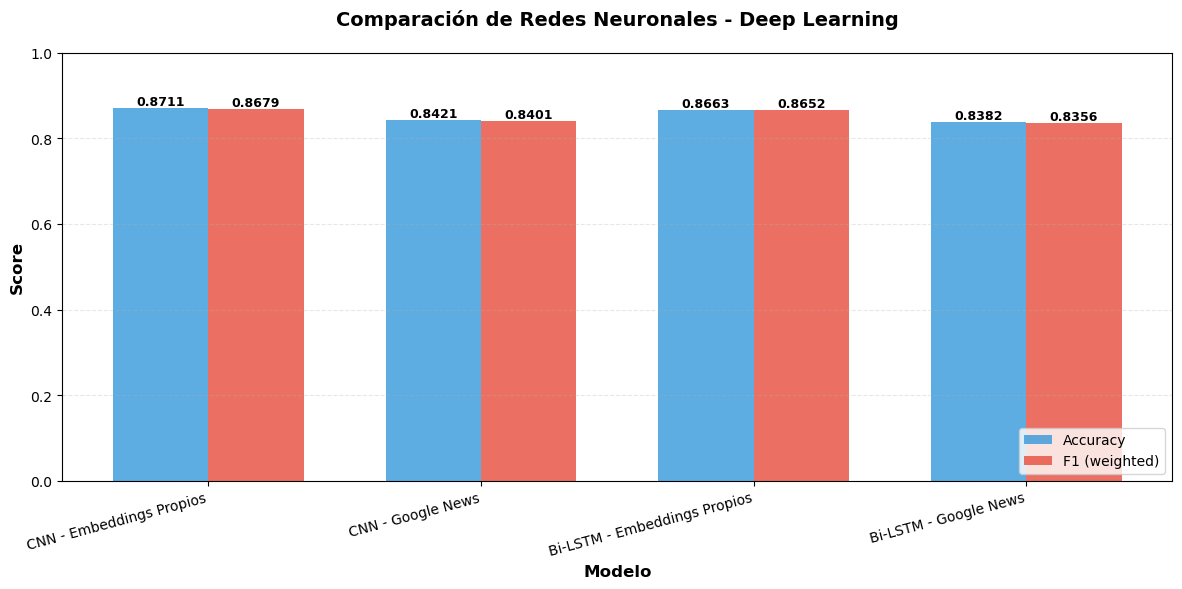


Mejor Accuracy: CNN - Embeddings Propios (0.8711)
Mejor F1: CNN - Embeddings Propios (0.8679)


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

resultados = {
    'Modelo': ['CNN - Embeddings Propios', 'CNN - Google News', 
               'Bi-LSTM - Embeddings Propios', 'Bi-LSTM - Google News'],
    'Accuracy': [acc_cnn_global, acc_cnn_pretrained, 
                 acc_bilstm_global, acc_bilstm_pretrained],
    'F1 (weighted)': [f1_cnn_global, f1_cnn_pretrained, 
                      f1_bilstm_global, f1_bilstm_pretrained]
}

df_resultados = pd.DataFrame(resultados)


fig, ax = plt.subplots(1, 1, figsize=(12, 6))
x = np.arange(len(df_resultados['Modelo']))
width = 0.35

bars1 = ax.bar(x - width/2, df_resultados['Accuracy'], width, label='Accuracy', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, df_resultados['F1 (weighted)'], width, label='F1 (weighted)', color='#e74c3c', alpha=0.8)

# Agregar valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')


ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Redes Neuronales - Deep Learning', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_resultados['Modelo'], rotation=15, ha='right')
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Comparacion
mejor_acc_idx = df_resultados['Accuracy'].idxmax()
mejor_f1_idx = df_resultados['F1 (weighted)'].idxmax()

print(f"\nMejor Accuracy: {df_resultados.loc[mejor_acc_idx, 'Modelo']} ({df_resultados.loc[mejor_acc_idx, 'Accuracy']:.4f})")
print(f"Mejor F1: {df_resultados.loc[mejor_f1_idx, 'Modelo']} ({df_resultados.loc[mejor_f1_idx, 'F1 (weighted)']:.4f})")

La comparación entre CNN y Bi-LSTM revela diferencias importantes. Mientras que la CNN captura patrones locales (g-grams) mediante sliding windows, la Bi-LSTM puede modelar dependencias a largo plazo en ambas direcciones del texto. El rendimiento de la CNN es ligeramente superior al de la Bi-LSTM (Menor tiempo de ejecucion y ligeramente mejores resultados), lo cual indica que los patrones locales de 5 palabras son suficientes para distinguir entre las categorías, siendo más eficiente computacionalmente.